In [1]:
import pandas as pd
import numpy as np
# from pandas_profiling import ProfileReport
# from ydata_profiling import ProfileReport
# すべての列を表示する設定
pd.set_option('display.max_columns', None)
# import seaborn as sns
import matplotlib.pyplot as plt
import japanize_matplotlib

# データ読み込み

In [2]:
land_data = pd.read_csv(r"D:\fujiwara\M\data\after_preprocess\land_data.csv")

C:\Users\GUESTUSER\AppData\Local\Temp\ipykernel_25100\3788408556.py:1: DtypeWarning: Columns (9,18,42) have mixed types. Specify dtype option on import or set low_memory=False.
  land_data = pd.read_csv(r"D:\fujiwara\M\data\after_preprocess\land_data.csv")


In [3]:
land_data["register_date"] = pd.to_datetime(land_data["register_date"] )

In [20]:
land_data.head()

,register_num,register_date,register_type,reason,pref,city,new_or_existing,type,location,chiban,...,id,line_name,station_name,on_foot,parcel_num,address_group,group_key,next_reason,next_date,days_until_next
0,905,2023-01-27,単独,分筆,三重県,いなべ市,既,土地,いなべ市北勢町下平,NaN,...,NaN,NaN,NaN,NaN,1047-1,三重県_いなべ市_いなべ市北勢町下平,三重県_いなべ市_いなべ市北勢町下平_1047-1,所有権移転売買,2023-02-22,26.0
1,1938,2023-02-22,単独,所有権移転売買,三重県,いなべ市,既,土地,いなべ市北勢町下平,NaN,...,NaN,NaN,NaN,NaN,1047-1,三重県_いなべ市_いなべ市北勢町下平,三重県_いなべ市_いなべ市北勢町下平_1047-1,NaN,NaN,NaN
2,2203,2023-02-28,単独,所有権移転遺贈・贈与その他無償名義,三重県,いなべ市,既,土地,いなべ市北勢町下平,NaN,...,NaN,NaN,NaN,NaN,1047-3,三重県_いなべ市_いなべ市北勢町下平,三重県_いなべ市_いなべ市北勢町下平_1047-3,地目変更・更正,2023-03-13,13.0
3,2838,2023-03-13,単独,地目変更・更正,三重県,いなべ市,既,土地,いなべ市北勢町下平,NaN,...,NaN,NaN,NaN,NaN,1047-3,三重県_いなべ市_いなべ市北勢町下平,三重県_いなべ市_いなべ市北勢町下平_1047-3,NaN,NaN,NaN
4,1195,2022-02-01,単独,所有権移転売買,三重県,いなべ市,既,土地,いなべ市北勢町下平,NaN,...,NaN,NaN,NaN,NaN,1220,三重県_いなべ市_いなべ市北勢町下平,三重県_いなべ市_いなべ市北勢町下平_1220,NaN,NaN,NaN


In [11]:
# Count the number of land sales per prefecture
land_sales_count_by_prefecture = land_data['pref'].value_counts().reset_index()
land_sales_count_by_prefecture.columns = ['Prefecture', 'Land Sales Count']

land_sales_count_by_prefecture

,Prefecture,Land Sales Count
0,東京都,8198869
1,静岡県,2834583
2,長野県,1937558
3,熊本県,1724022
4,茨城県,1683877
5,鹿児島県,1599108
6,神奈川県,1364520
7,埼玉県,1254018
8,千葉県,1147315
9,青森県,936344


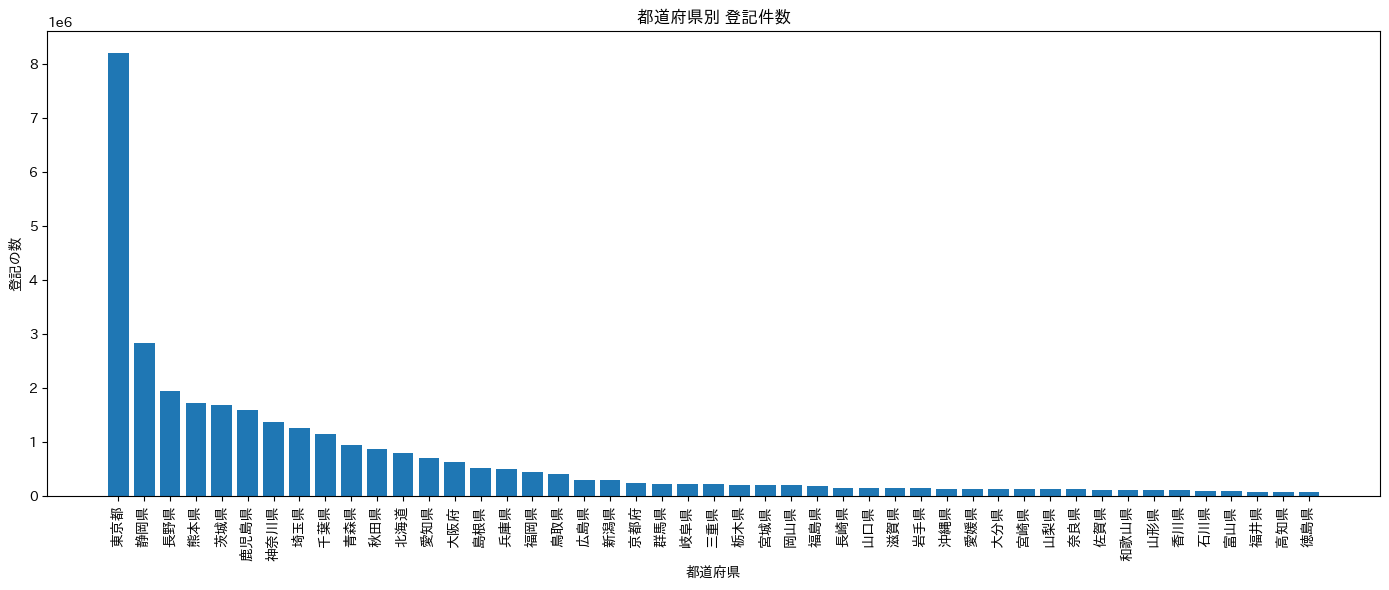

In [13]:
# 登記件数でソート（多い順）
land_sales_count_sorted = land_sales_count_by_prefecture.sort_values(
    by="Land Sales Count", ascending=False
)

# 棒グラフ（縦）
plt.figure(figsize=(14, 6))
plt.bar(
    land_sales_count_sorted["Prefecture"],
    land_sales_count_sorted["Land Sales Count"]
)

plt.xlabel("都道府県")
plt.ylabel("登記の数")
plt.title("都道府県別 登記件数")

# 都道府県名が重ならないように回転
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


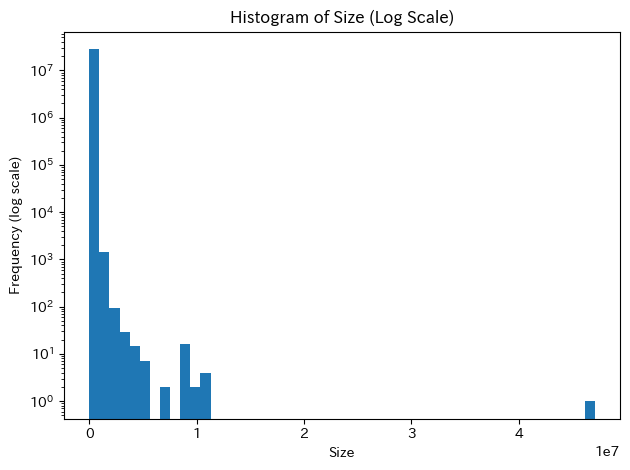

In [12]:
plt.figure()
plt.hist(land_data["size"].dropna(), bins=50)
plt.yscale("log")
plt.xlabel("Size")
plt.ylabel("Frequency (log scale)")
plt.title("Histogram of Size (Log Scale)")
plt.tight_layout()
plt.show()


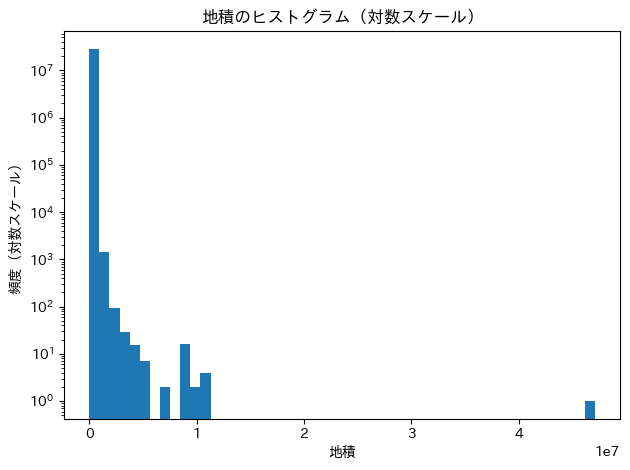

In [4]:
# 地積のヒストグラム（対数スケール）
plt.figure()
plt.hist(land_data["size"].dropna(), bins=50)
plt.yscale("log")
plt.xlabel("地積")
plt.ylabel("頻度（対数スケール）")
plt.title("地積のヒストグラム（対数スケール）")
plt.tight_layout()
plt.show()


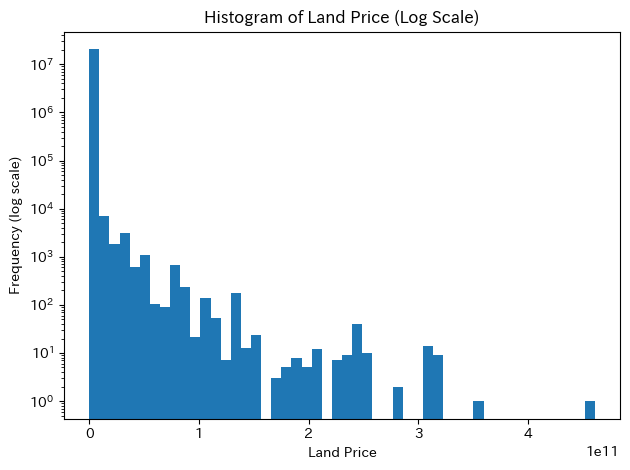

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(land_data["land_price"].dropna(), bins=50)
plt.yscale("log")
plt.xlabel("Land Price")
plt.ylabel("Frequency (log scale)")
plt.title("Histogram of Land Price (Log Scale)")
plt.tight_layout()
plt.show()


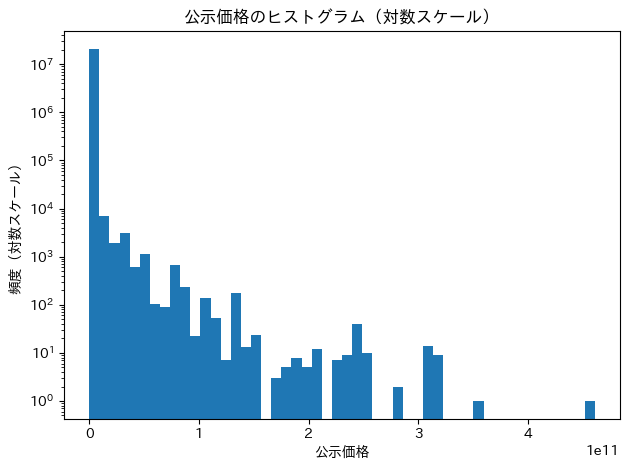

In [5]:
# 公示価格のヒストグラム（対数スケール）
plt.figure()
plt.hist(land_data["land_price"].dropna(), bins=50)
plt.yscale("log")
plt.xlabel("公示価格")
plt.ylabel("頻度（対数スケール）")
plt.title("公示価格のヒストグラム（対数スケール）")
plt.tight_layout()
plt.show()


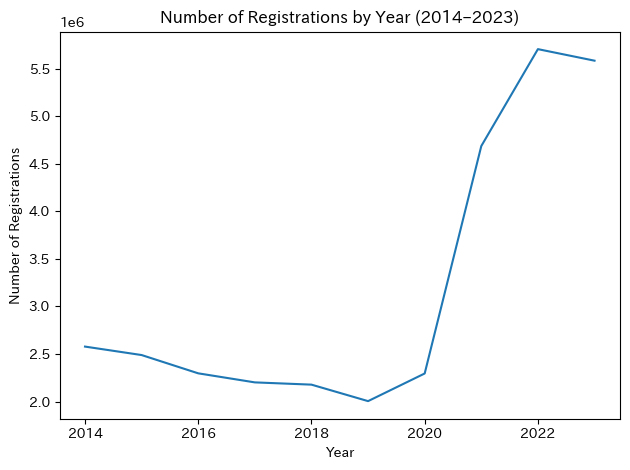

In [22]:
# 年ごとの登記数（2014–2023）
year_counts = (
    land_data["register_date"]
    .dt.year
    .value_counts()
    .sort_index()
)

# 折れ線グラフ
plt.figure()
plt.plot(year_counts.index, year_counts.values)
plt.xlabel("Year")
plt.ylabel("Number of Registrations")
plt.title("Number of Registrations by Year (2014–2023)")
plt.tight_layout()
plt.show()


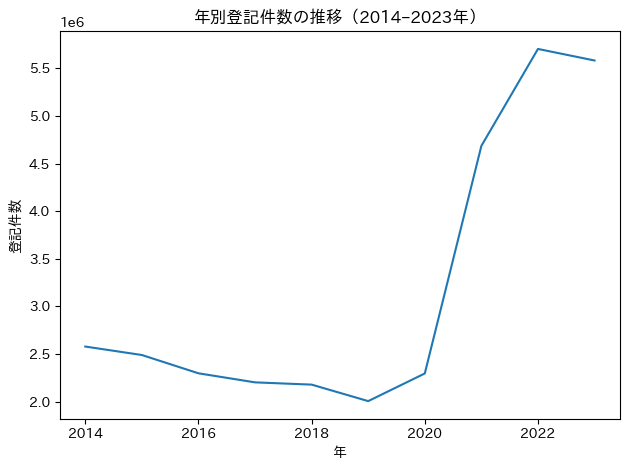

In [6]:
# 年ごとの登記数（2014–2023）
year_counts = (
    land_data["register_date"]
    .dt.year
    .value_counts()
    .sort_index()
)
# 年ごとの登記件数（2014–2023）
plt.figure()
plt.plot(year_counts.index, year_counts.values)
plt.xlabel("年")
plt.ylabel("登記件数")
plt.title("年別登記件数の推移（2014–2023年）")
plt.tight_layout()
plt.show()


In [25]:
land_data["reason"].unique()

array(['分筆', '所有権移転売買', '所有権移転遺贈・贈与その他無償名義', '地目変更・更正', '権利の変更・更正',
       '登記名義人の氏名等についての変更・更正', '所有権移転相続・法人合併', '抹消登記', '抵当権の設定',
       '処分の制限に関する登記', '地積変更・更正', '仮登記(その他)', '合筆', '所有権の保存(申請)',
       '所有権移転その他の原因', '権利の移転(所有権を除く)', '共同担保変更通知', '表題', '仮登記(所有権)', '滅失',
       '信託に関する登記', '共同担保追加通知', '所有権移転遺贈・贈与その他', '抹消登記/嘱託',
       '処分の制限に関する登記/嘱託'], dtype=object)

In [29]:
import pandas as pd

# reason ごとの件数（降順）
reason_table = (
    land_data["reason"]
    .value_counts()
    .reset_index()
)

# 列名を明示
reason_table.columns = ["Reason", "Count"]

reason_table


,Reason,Count
0,所有権移転売買,6821321
1,抹消登記,5538268
2,抵当権の設定,4657098
3,所有権移転相続・法人合併,4138929
4,登記名義人の氏名等についての変更・更正,3518923
5,分筆,1541561
6,地目変更・更正,1345813
7,権利の変更・更正,1059710
8,所有権移転遺贈・贈与その他無償名義,937675
9,所有権移転その他の原因,667546


In [8]:
df = pd.read_csv(r"D:\fujiwara\M\data\after_preprocess\land_data_for_prediction.csv")

In [34]:
import matplotlib.pyplot as plt

next_reason_cols = [
    col for col in df.columns
    if col.startswith("on_day_reason_group_") and col.endswith("_next")
]

reason_label_en = {
    "on_day_reason_group_sale_next": "Sale",
    "on_day_reason_group_inheritance_or_gift_transfer_next": "Inheritance / Gift Transfer",
    "on_day_reason_group_other_causes_transfer_next": "Other Ownership Transfer",
    "on_day_reason_group_collateral_next": "Collateral-related",
    "on_day_reason_group_ownership_origin_next": "Initial Ownership Registration",
    "on_day_reason_group_physical_change_next": "Physical Changes (Parcel Split/Merge)",
    "on_day_reason_group_title_registration_next": "Title Registration",
    "on_day_reason_group_restriction_next": "Restrictions",
    "on_day_reason_group_title_or_right_correction_next": "Name / Right Correction",
    "on_day_reason_group_cancellation_next": "Cancellation"
}

reason_label_ja = {
    "on_day_reason_group_sale_next": "売買",
    "on_day_reason_group_inheritance_or_gift_transfer_next": "相続・贈与などの所有権移転",
    "on_day_reason_group_other_causes_transfer_next": "その他の理由による所有権移転",
    "on_day_reason_group_collateral_next": "抵当権関連",
    "on_day_reason_group_ownership_origin_next": "所有権の初期設定",
    "on_day_reason_group_physical_change_next": "地番の分筆・合筆などの物理的変化",
    "on_day_reason_group_title_registration_next": "表題登記",
    "on_day_reason_group_restriction_next": "制限関連",
    "on_day_reason_group_title_or_right_correction_next": "名義・権利の修正",
    "on_day_reason_group_cancellation_next": "抹消"
}


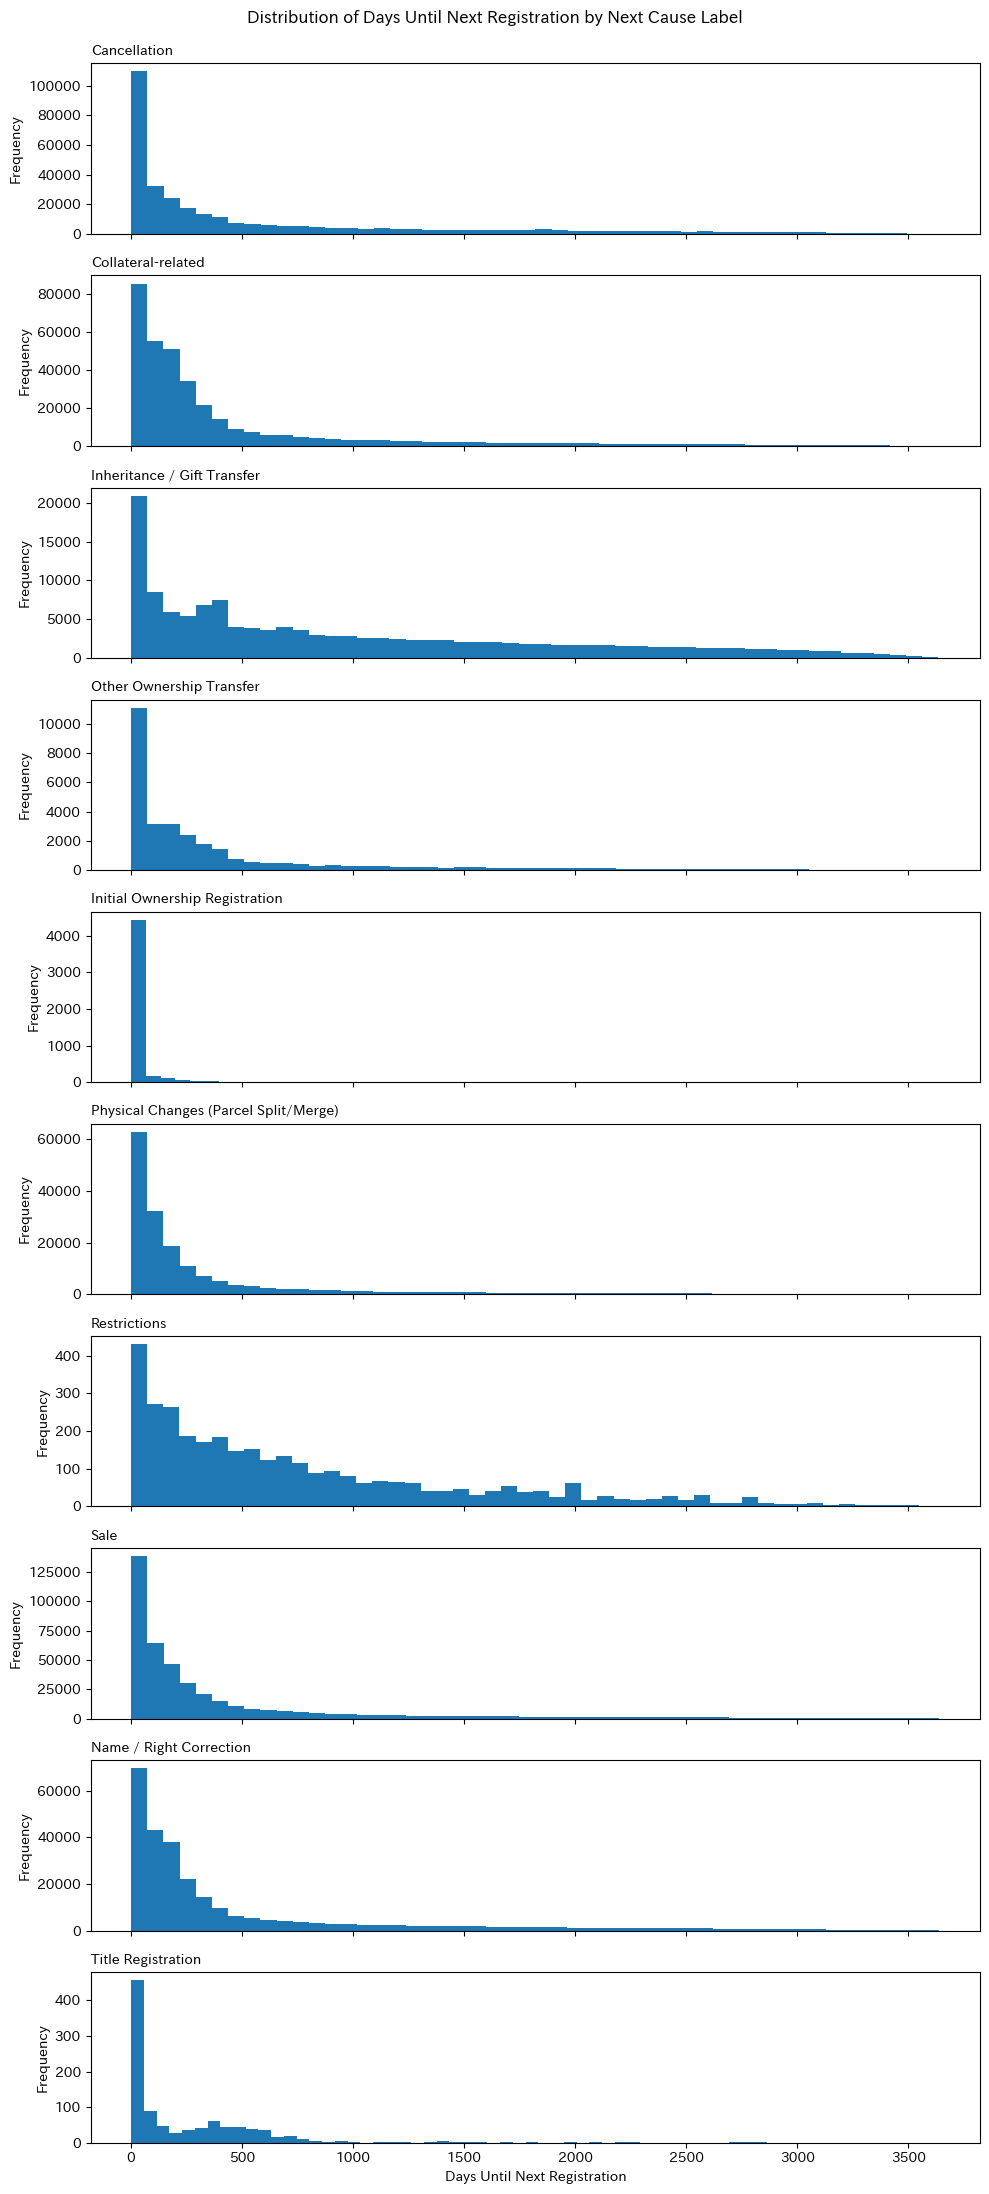

In [39]:
fig, axes = plt.subplots(len(next_reason_cols), 1, figsize=(10, 2.2 * len(next_reason_cols)), sharex=True)

for ax, col in zip(axes, next_reason_cols):
    subset = df[df[col] == 1]["days_until_next"].dropna()
    ax.hist(subset, bins=50)
    ax.set_ylabel("Frequency")
    ax.set_title(reason_label_en[col], loc="left", fontsize=10)

axes[-1].set_xlabel("Days Until Next Registration")
fig.suptitle("Distribution of Days Until Next Registration by Next Cause Label", y=0.995)
plt.tight_layout()
plt.show()


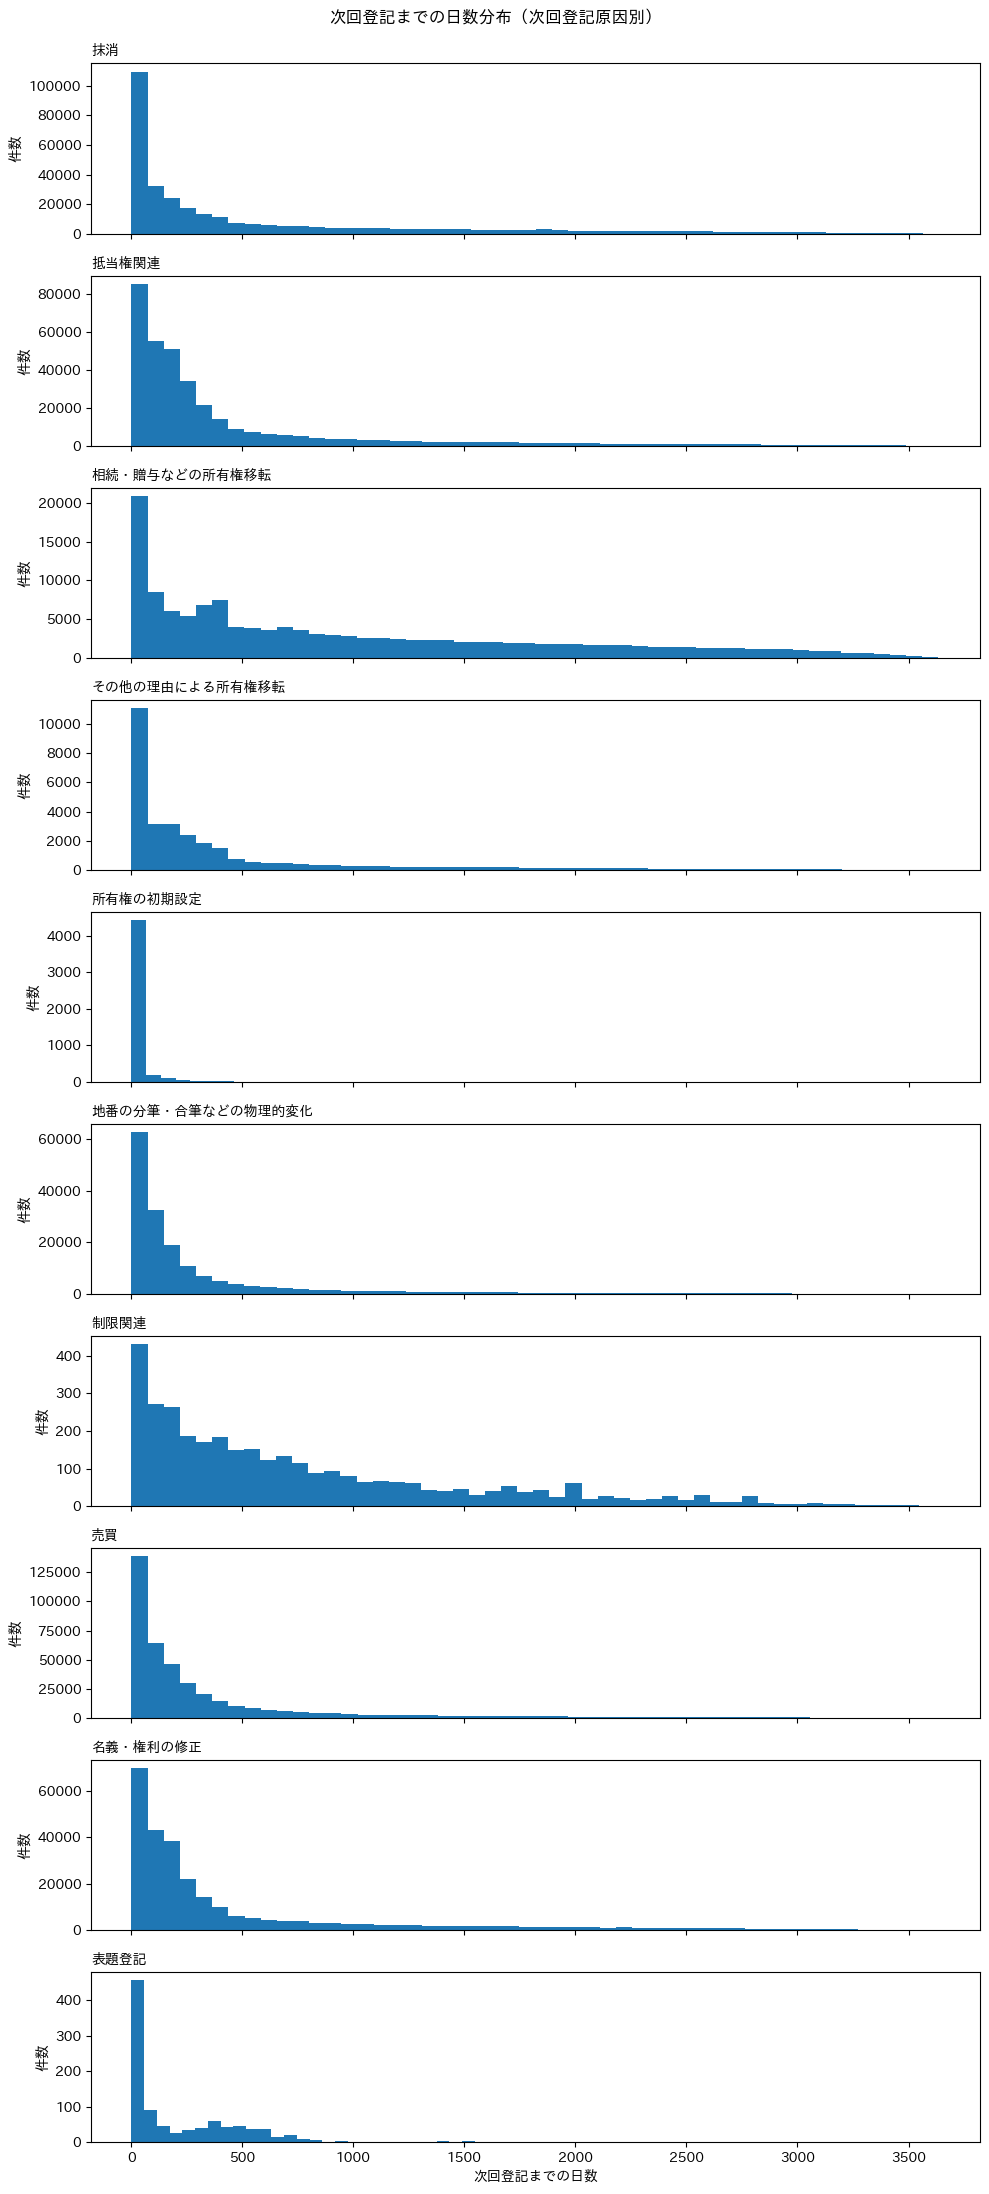

In [36]:
fig, axes = plt.subplots(len(next_reason_cols), 1, figsize=(10, 2.2 * len(next_reason_cols)), sharex=True)

for ax, col in zip(axes, next_reason_cols):
    subset = df[df[col] == 1]["days_until_next"].dropna()
    ax.hist(subset, bins=50)
    ax.set_ylabel("件数")
    ax.set_title(reason_label_ja[col], loc="left", fontsize=10)

axes[-1].set_xlabel("次回登記までの日数")
fig.suptitle("次回登記までの日数分布（次回登記原因別）", y=0.995)
plt.tight_layout()
plt.show()


In [40]:
import matplotlib.pyplot as plt

# 当該登記原因（_next なし）
reason_cols = [
    col for col in df.columns
    if col.startswith("on_day_reason_group_") and not col.endswith("_next")
]

# 英語ラベル
reason_label_en = {
    "on_day_reason_group_sale": "Sale",
    "on_day_reason_group_inheritance_or_gift_transfer": "Inheritance / Gift Transfer",
    "on_day_reason_group_other_causes_transfer": "Other Ownership Transfer",
    "on_day_reason_group_collateral": "Collateral-related",
    "on_day_reason_group_ownership_origin": "Initial Ownership Registration",
    "on_day_reason_group_physical_change": "Physical Changes (Parcel Split/Merge)",
    "on_day_reason_group_title_registration": "Title Registration",
    "on_day_reason_group_restriction": "Restrictions",
    "on_day_reason_group_title_or_right_correction": "Name / Right Correction",
    "on_day_reason_group_cancellation": "Cancellation"
}

# 日本語ラベル
reason_label_ja = {
    "on_day_reason_group_sale": "売買",
    "on_day_reason_group_inheritance_or_gift_transfer": "相続・贈与などの所有権移転",
    "on_day_reason_group_other_causes_transfer": "その他の理由による所有権移転",
    "on_day_reason_group_collateral": "抵当権関連",
    "on_day_reason_group_ownership_origin": "所有権の初期設定",
    "on_day_reason_group_physical_change": "地番の分筆・合筆などの物理的変化",
    "on_day_reason_group_title_registration": "表題登記",
    "on_day_reason_group_restriction": "制限関連",
    "on_day_reason_group_title_or_right_correction": "名義・権利の修正",
    "on_day_reason_group_cancellation": "抹消"
}


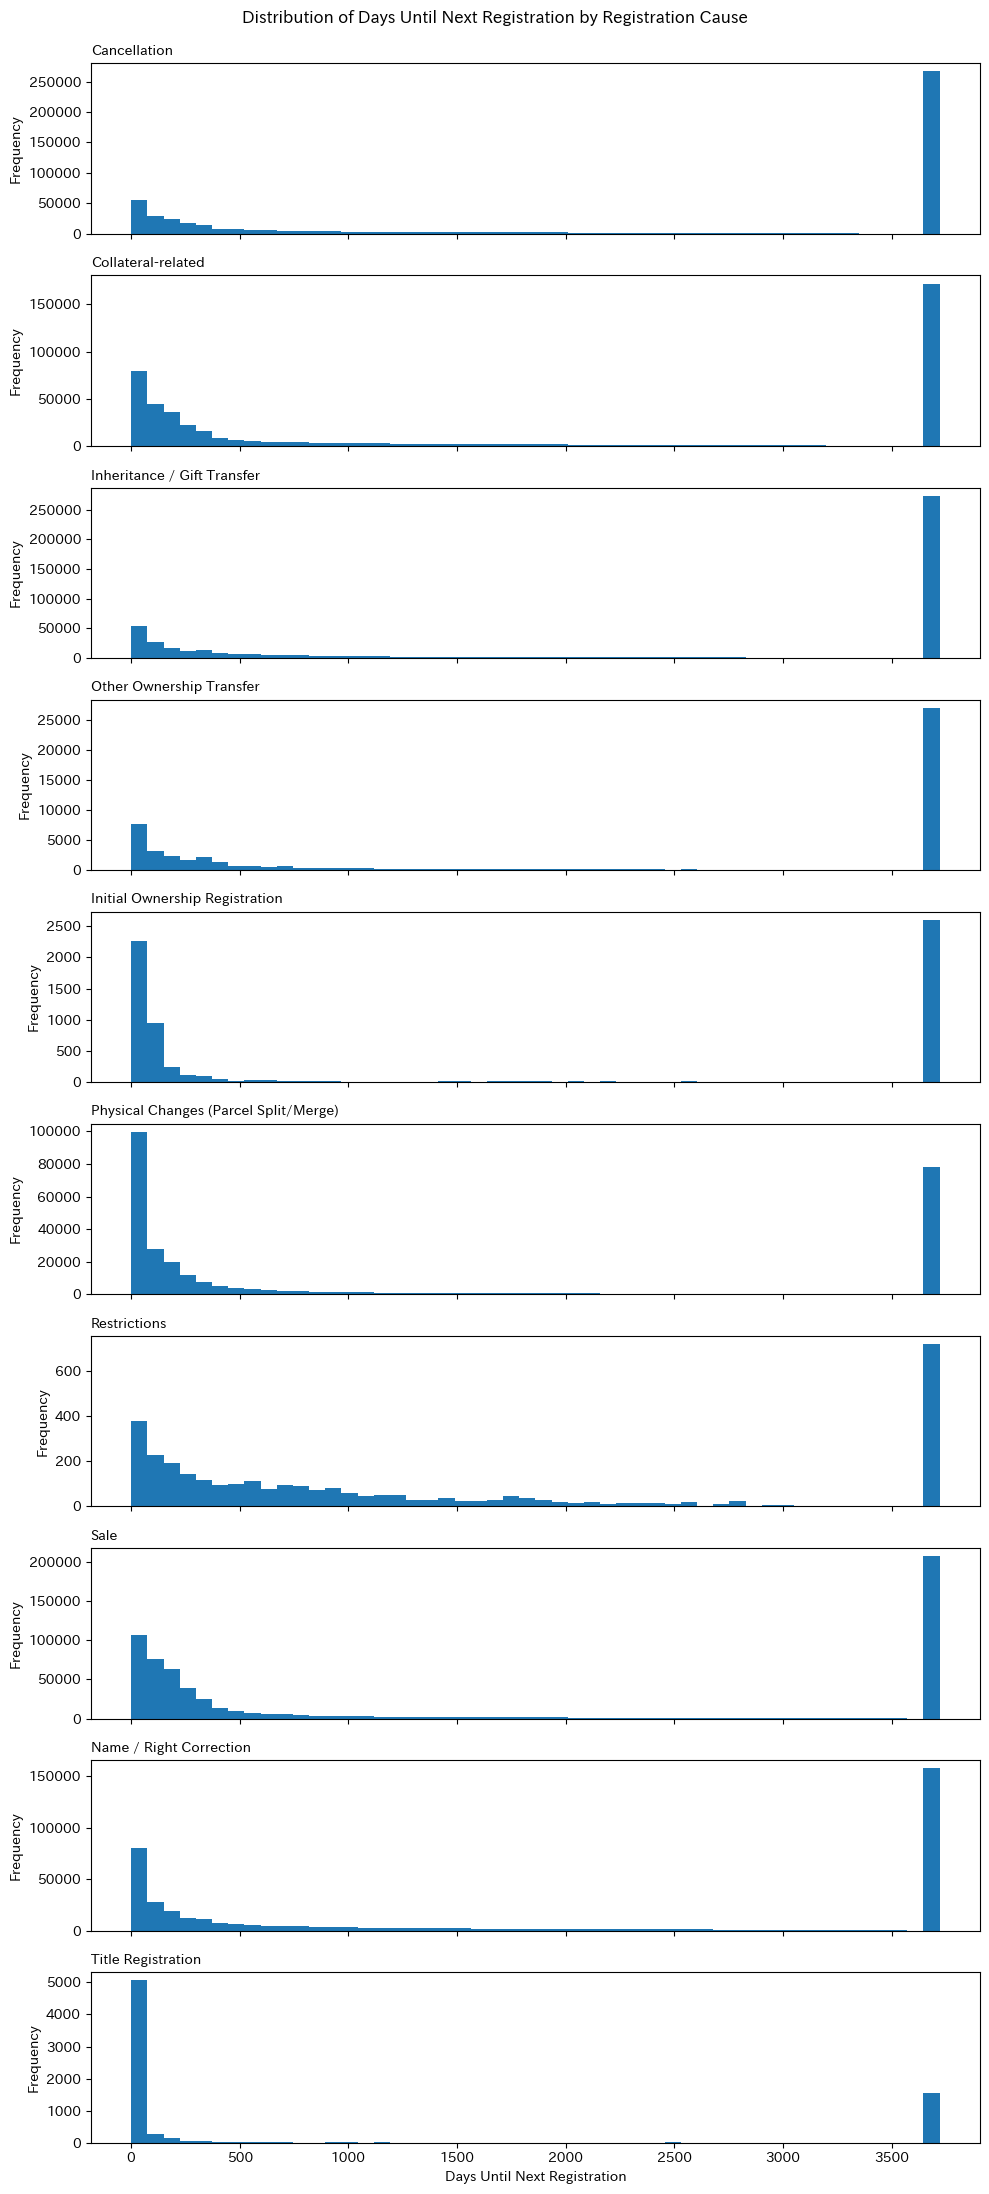

In [41]:
fig, axes = plt.subplots(
    len(reason_cols),
    1,
    figsize=(10, 2.2 * len(reason_cols)),
    sharex=True
)

for ax, col in zip(axes, reason_cols):
    subset = df[df[col] == 1]["days_until_next"].dropna()
    ax.hist(subset, bins=50)
    ax.set_ylabel("Frequency")
    ax.set_title(reason_label_en[col], loc="left", fontsize=10)

axes[-1].set_xlabel("Days Until Next Registration")
fig.suptitle(
    "Distribution of Days Until Next Registration by Registration Cause",
    y=0.995
)
plt.tight_layout()
plt.show()


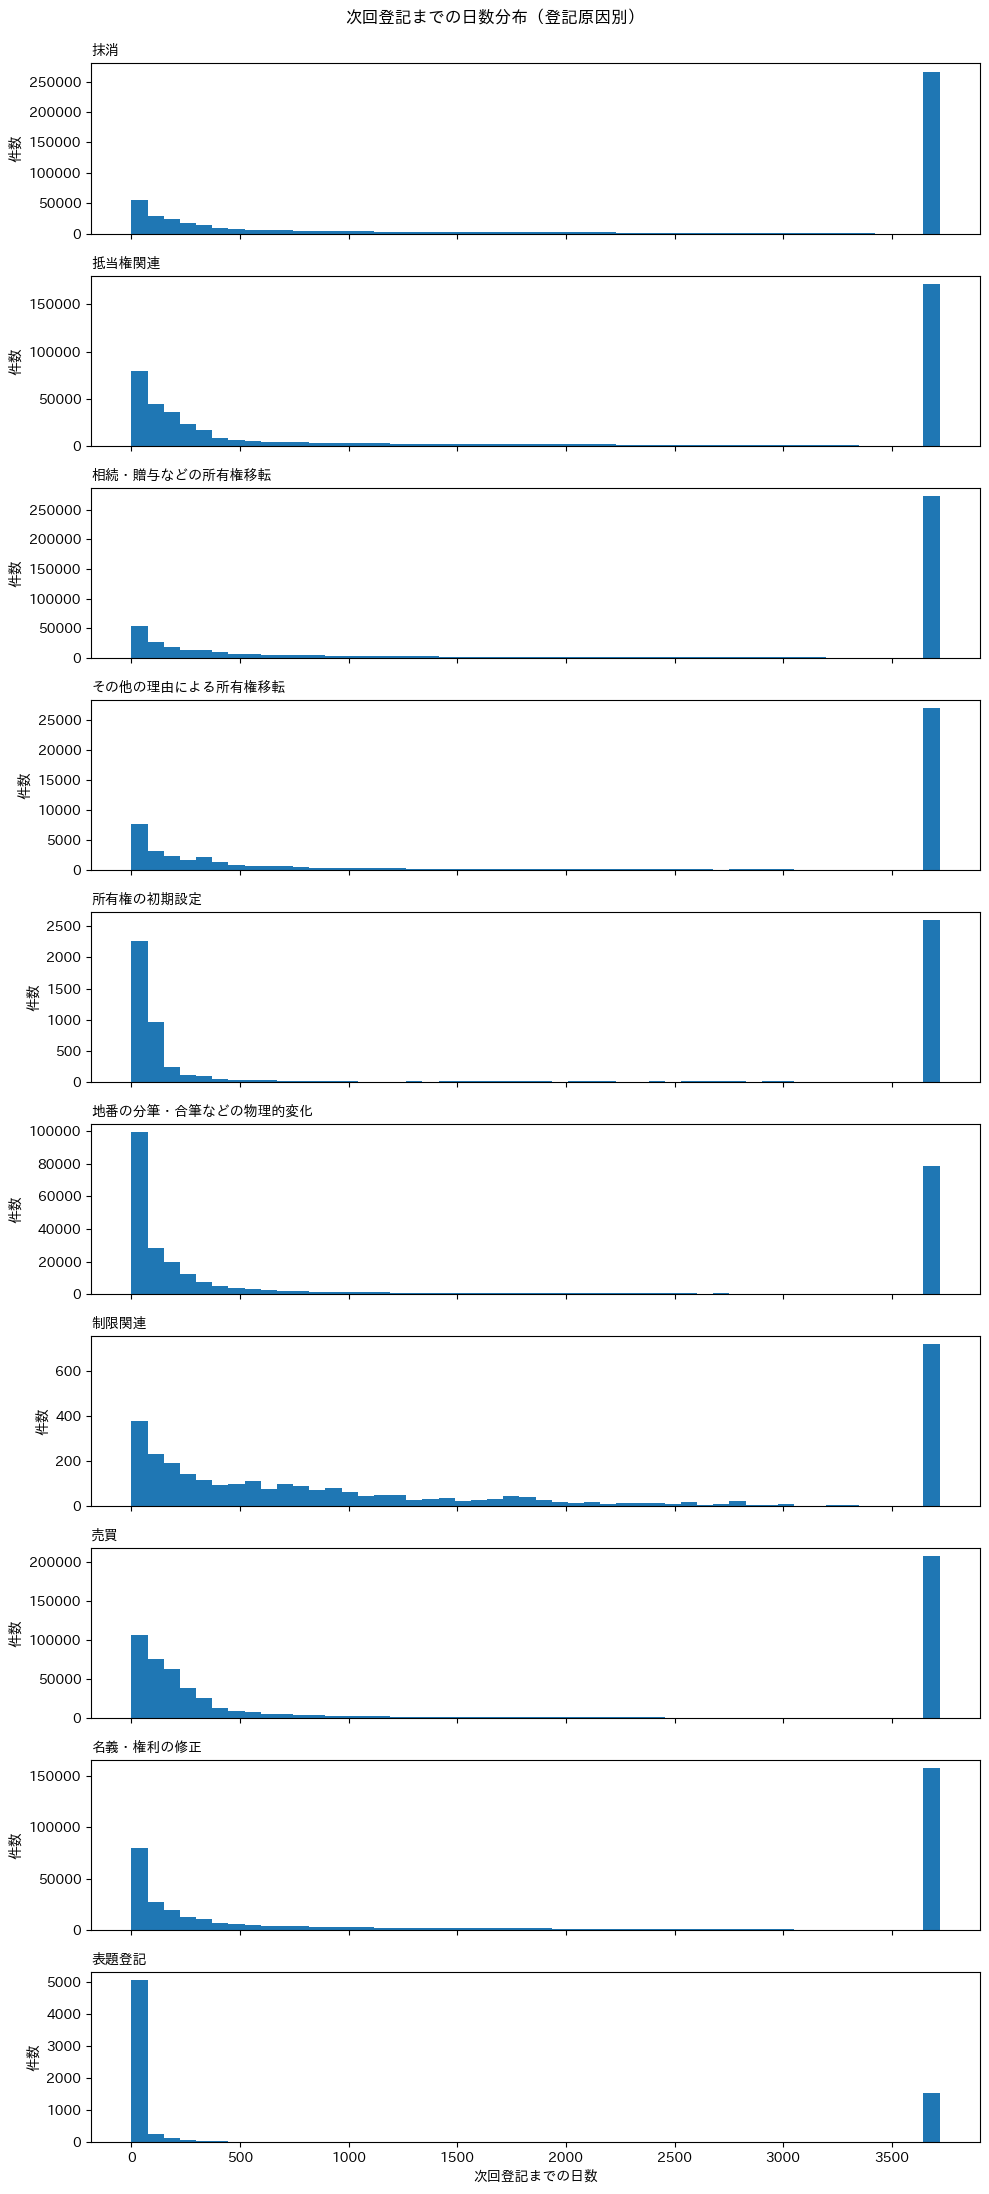

In [42]:
fig, axes = plt.subplots(
    len(reason_cols),
    1,
    figsize=(10, 2.2 * len(reason_cols)),
    sharex=True
)

for ax, col in zip(axes, reason_cols):
    subset = df[df[col] == 1]["days_until_next"].dropna()
    ax.hist(subset, bins=50)
    ax.set_ylabel("件数")
    ax.set_title(reason_label_ja[col], loc="left", fontsize=10)

axes[-1].set_xlabel("次回登記までの日数")
fig.suptitle(
    "次回登記までの日数分布（登記原因別）",
    y=0.995
)
plt.tight_layout()
plt.show()


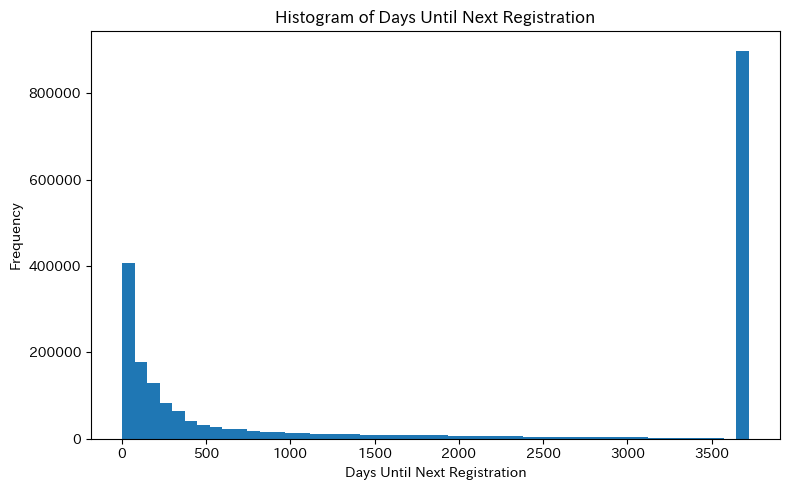

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["days_until_next"].dropna(), bins=50)
plt.xlabel("Days Until Next Registration")
plt.ylabel("Frequency")
plt.title("Histogram of Days Until Next Registration")
plt.tight_layout()
plt.show()


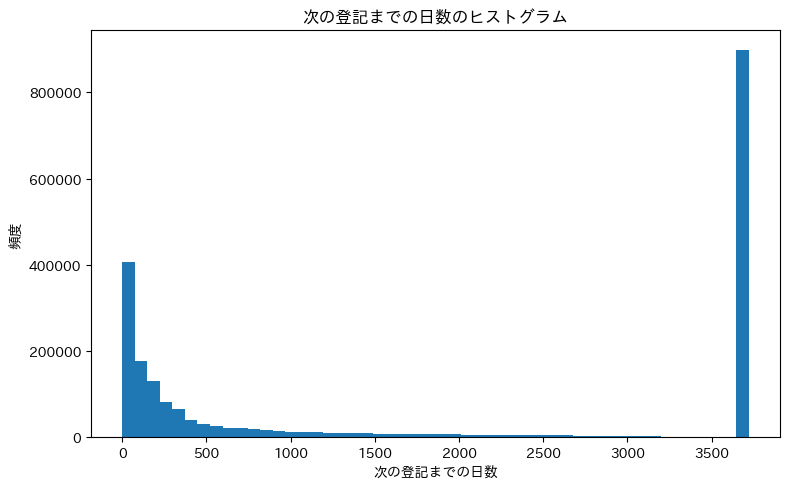

In [9]:
# 次の登記までの日数のヒストグラム
plt.figure(figsize=(8, 5))
plt.hist(df["days_until_next"].dropna(), bins=50)
plt.xlabel("次の登記までの日数")
plt.ylabel("頻度")
plt.title("次の登記までの日数のヒストグラム")
plt.tight_layout()
plt.show()
